In [1]:
import pandas as pd
import numpy as np

# =========================
# 1) Load dataset
# =========================
df = pd.read_csv("diabetic_data.csv")

print("Initial shape:", df.shape)
display(df.head())

# =========================
# 2) Replace "?" with NaN
# =========================
df.replace("?", np.nan, inplace=True)

# =========================
# 3) Drop columns with very high missingness or not useful for modeling
# =========================
cols_to_drop = [
    "weight",               # extremely high missingness
    "payer_code",           # very high missingness
    "medical_specialty",     # very high missingness
    "encounter_id",          # identifier
    "patient_nbr",           # identifier
    "max_glu_serum",        # very high missingness
    "A1Cresult"             # very high missingness
]

df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# =========================
# 4) Handle missing values in low-missing columns
# =========================
# Fill categorical missing values with "Unknown"
for col in ["race", "diag_1", "diag_2", "diag_3"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Remove rows with invalid gender
if "gender" in df.columns:
    df = df[df["gender"] != "Unknown/Invalid"].copy()

# =========================
# 5) Convert age bands to numeric midpoints
# =========================
age_map = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

if "age" in df.columns:
    df["age"] = df["age"].map(age_map)

# =========================
# 6) Create target variable
#    readmitted <30 -> 1
#    readmitted NO / >30 -> 0
# =========================
if "readmitted" in df.columns:
    df["target"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)
    df.drop(columns=["readmitted"], inplace=True)

# =========================
# 7) Remove duplicate rows
# =========================
df.drop_duplicates(inplace=True)

# =========================
# 8) Reset index
# =========================
df.reset_index(drop=True, inplace=True)

# =========================
# 9) Final checks
# =========================
print("\nFinal shape:", df.shape)
print("\nTarget distribution (%):")
print((df["target"].value_counts(normalize=True) * 100).round(2))

print("\nRemaining missing values:")
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": (df.isnull().mean() * 100).round(2)
})
print(missing[missing["Missing_Count"] > 0].sort_values("Missing_%", ascending=False))

display(df.head())

# =========================
# 10) Save cleaned file
# =========================
df.to_csv("diabetic_data_cleaned.csv", index=False)
print("\nSaved as diabetic_data_cleaned.csv")

Initial shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Final shape: (101763, 43)

Target distribution (%):
target
0    88.84
1    11.16
Name: proportion, dtype: float64

Remaining missing values:
Empty DataFrame
Columns: [Missing_Count, Missing_%]
Index: []


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,Caucasian,Female,5,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,15,1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,35,1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,45,1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0



Saved as diabetic_data_cleaned.csv


In [2]:
df.shape
df["target"].value_counts(normalize=True) * 100

,proportion
target,
0,88.839755
1,11.160245


## Data Cleaning Summary

1. Replaced '?' with NaN
2. Dropped weight (97% missing)
3. Dropped payer_code (40%+ missing)
4. Dropped medical_specialty (47%+ missing)
5. Dropped max_glu_serum (89% missing)
6. Dropped A1Cresult (84% missing)
7. Removed identifiers
8. Filled low-missing diagnosis fields
9. Converted age groups to numeric midpoints
10. Created binary target variable
11. Removed invalid gender records
12. Removed duplicates

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

sns.set_style("whitegrid")

Shape: (101763, 43)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,Caucasian,Female,5,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,15,1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,35,1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,45,1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101763 entries, 0 to 101762
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101763 non-null  object
 1   gender                    101763 non-null  object
 2   age                       101763 non-null  int64 
 3   admission_type_id         101763 non-null  int64 
 4   discharge_disposition_id  101763 non-null  int64 
 5   admission_source_id       101763 non-null  int64 
 6   time_in_hospital          101763 non-null  int64 
 7   num_lab_procedures        101763 non-null  int64 
 8   num_procedures            101763 non-null  int64 
 9   num_medications           101763 non-null  int64 
 10  number_outpatient         101763 non-null  int64 
 11  number_emergency          101763 non-null  int64 
 12  number_inpatient          101763 non-null  int64 
 13  diag_1                    101763 non-null  object
 1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
race,101763,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101763,2,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101763.0,NaN,NaN,NaN,65.966854,15.941022,5.0,55.0,65.0,75.0,95.0
admission_type_id,101763.0,NaN,NaN,NaN,2.024017,1.445414,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101763.0,NaN,NaN,NaN,3.715515,5.279919,1.0,1.0,1.0,4.0,28.0
admission_source_id,101763.0,NaN,NaN,NaN,5.754459,4.06411,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101763.0,NaN,NaN,NaN,4.396018,2.985092,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101763.0,NaN,NaN,NaN,43.095909,19.67422,1.0,31.0,44.0,57.0,132.0
num_procedures,101763.0,NaN,NaN,NaN,1.339691,1.705792,0.0,0.0,1.0,2.0,6.0
num_medications,101763.0,NaN,NaN,NaN,16.021835,8.127589,1.0,10.0,15.0,20.0,81.0



Target distribution (%):


,proportion
target,
0,88.84
1,11.16



Missing values:


,Missing_Count,Missing_%


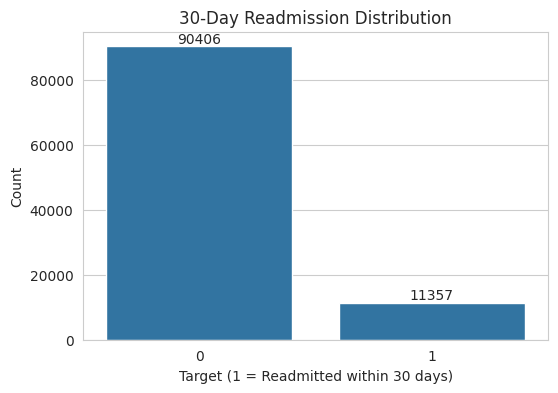

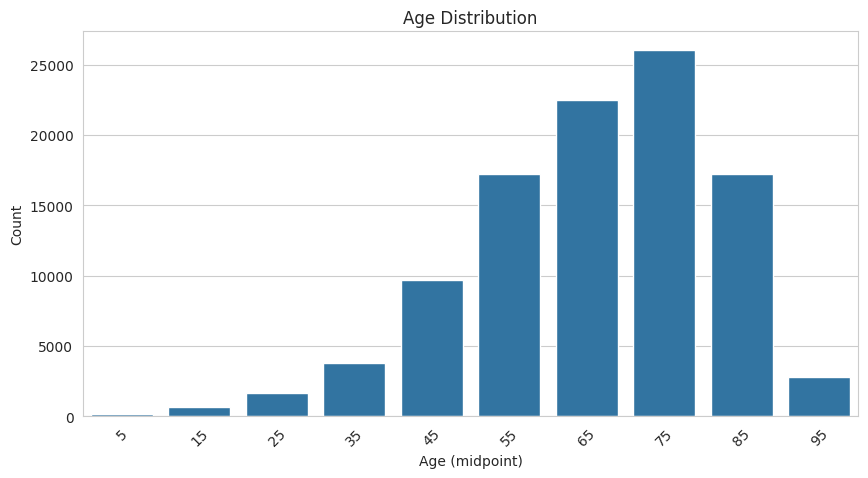

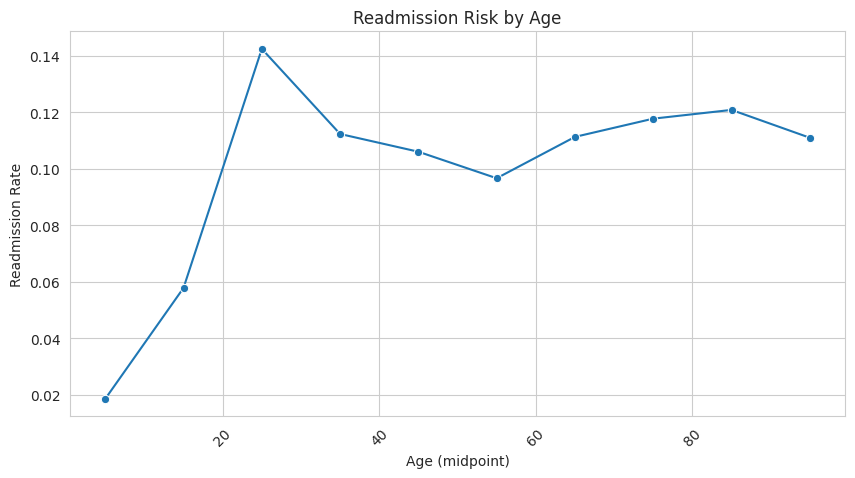

,age,target
0,5,0.018634
1,15,0.057887
2,25,0.142426
3,35,0.112318
4,45,0.106040
5,55,0.096662
6,65,0.111289
7,75,0.117740
8,85,0.120835
9,95,0.110992


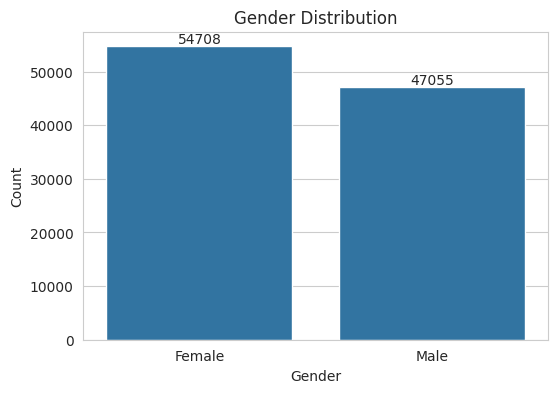

,gender,target
0,Female,0.112452
1,Male,0.110615


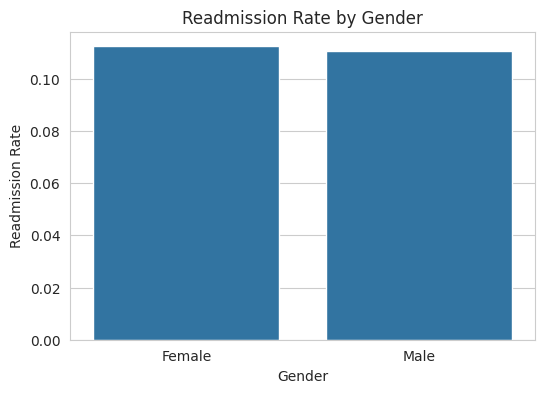

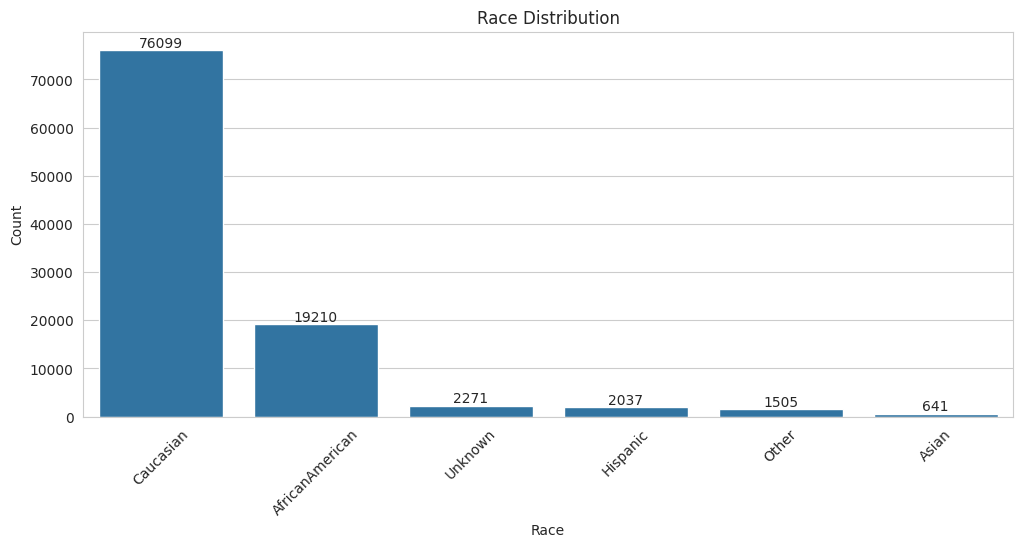

,race,target
2,Caucasian,0.112906
0,AfricanAmerican,0.112181
3,Hispanic,0.104075
1,Asian,0.101404
4,Other,0.096346
5,Unknown,0.082783


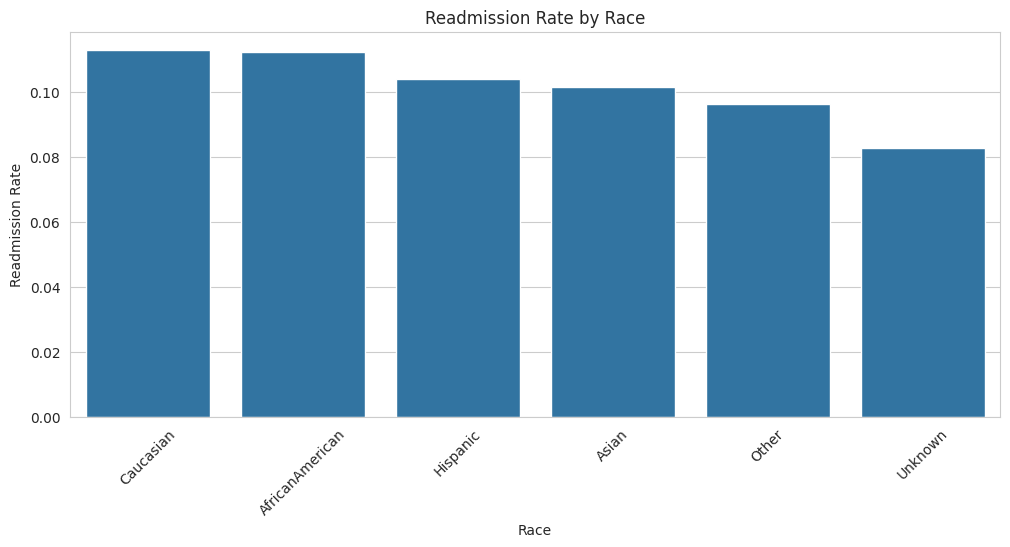

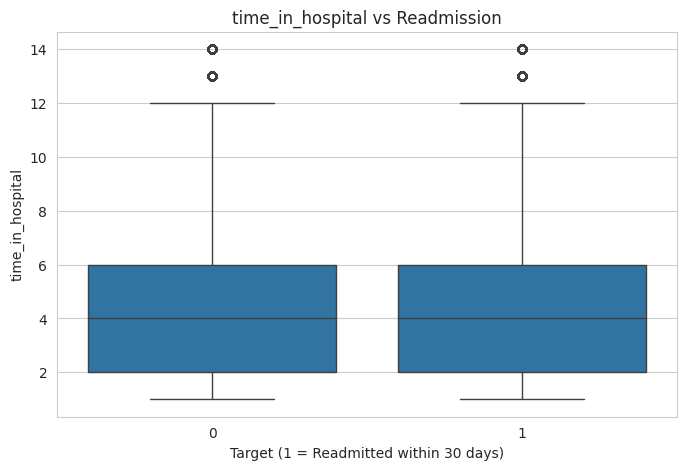

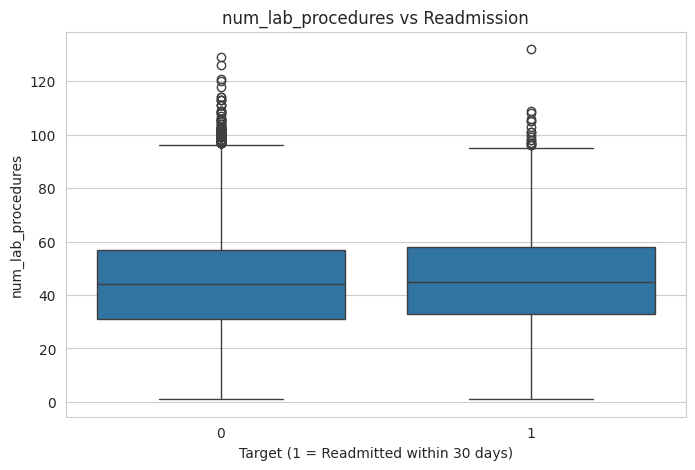

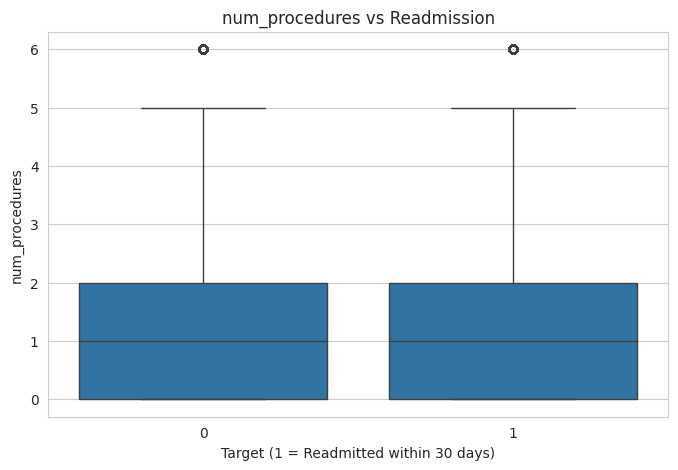

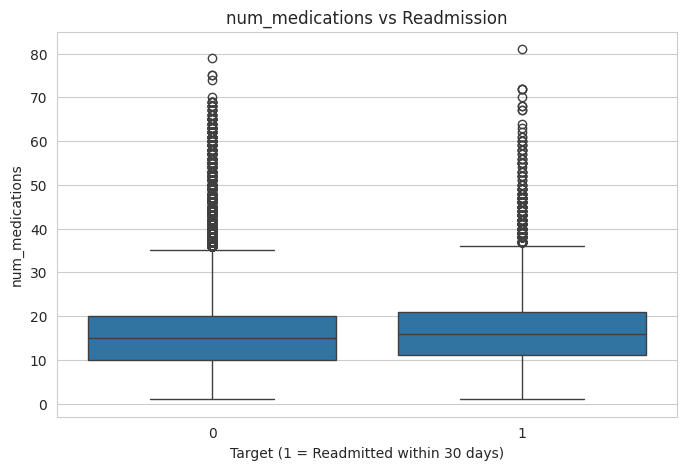

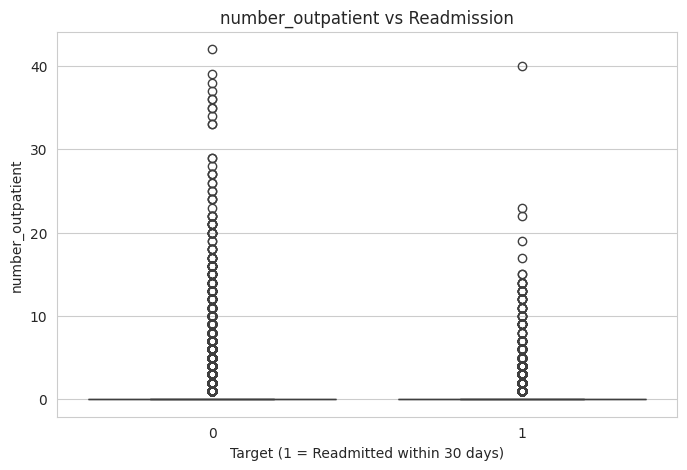

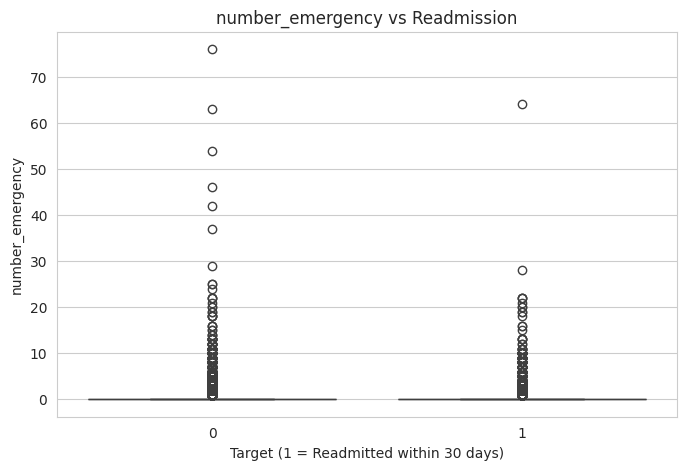

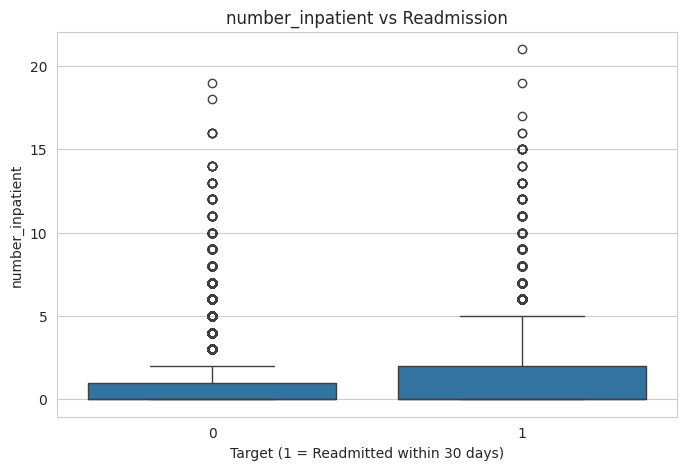

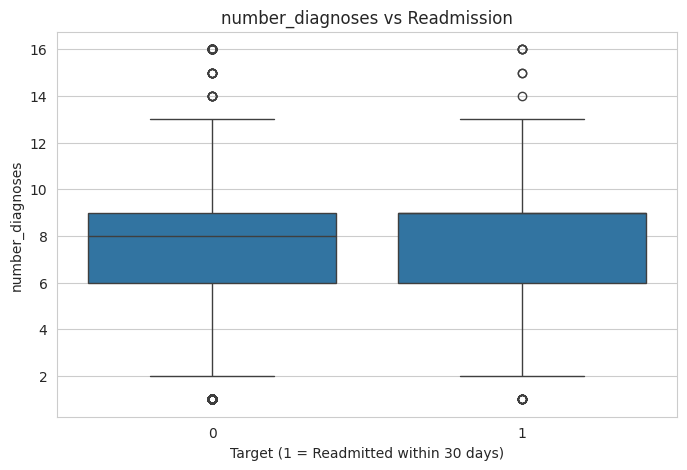

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
target,,,,,,,,
0,4.35,42.95,1.35,15.91,0.36,0.18,0.56,7.39
1,4.77,44.23,1.28,16.90,0.44,0.36,1.22,7.69


Mann-Whitney U test results:
time_in_hospital: p-value = 0.0000000000
num_medications: p-value = 0.0000000000
number_inpatient: p-value = 0.0000000000
number_diagnoses: p-value = 0.0000000000


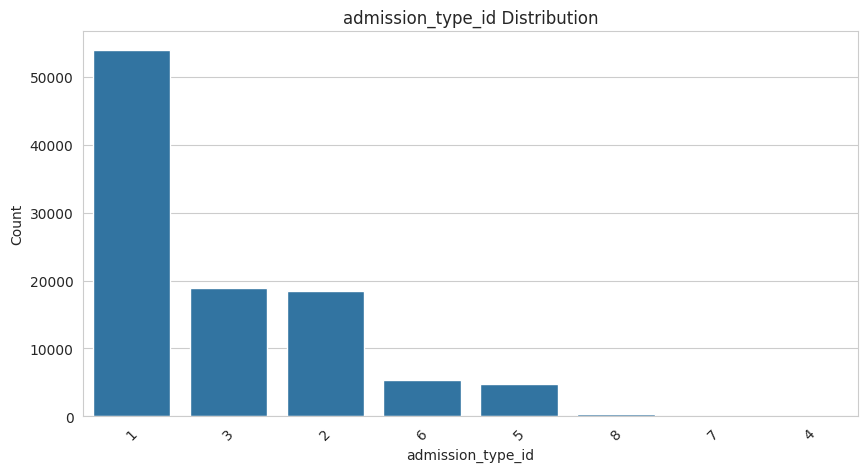

,admission_type_id,target
0,1,0.115229
1,2,0.111797
5,6,0.110754
2,3,0.103933
4,5,0.103448
3,4,0.100000
7,8,0.084375
6,7,0.000000


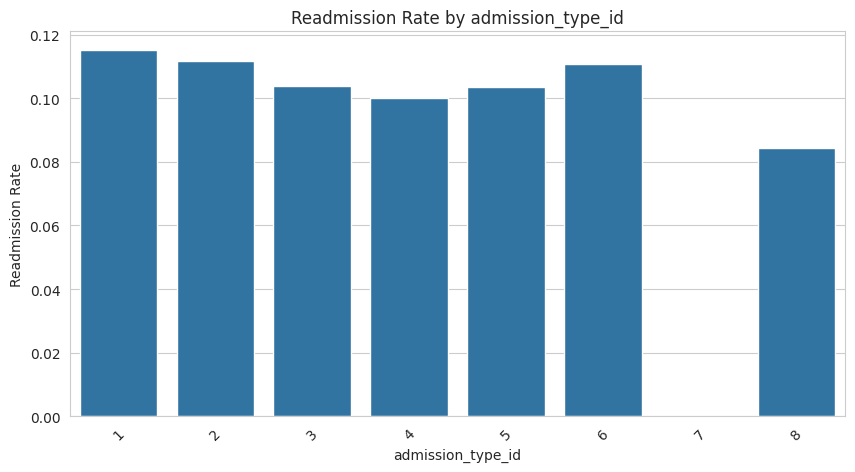

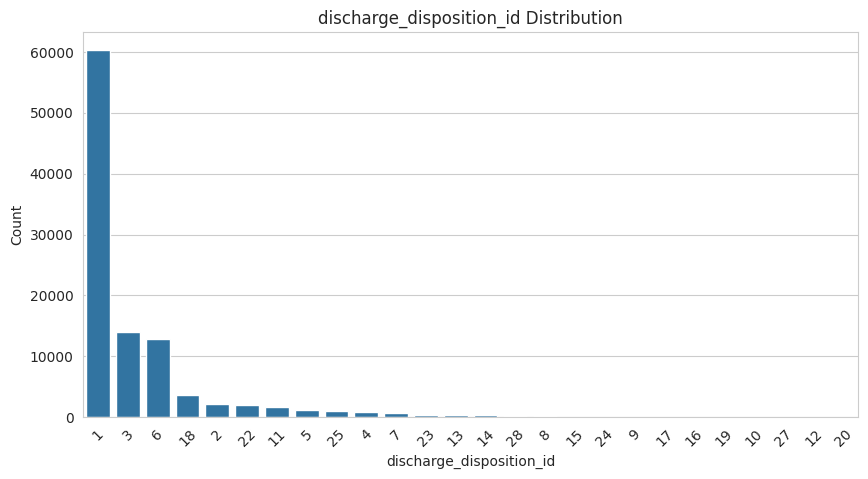

,discharge_disposition_id,target
11,12,0.666667
14,15,0.444444
8,9,0.428571
25,28,0.366906
20,22,0.277108
4,5,0.208615
1,2,0.160714
2,3,0.146625
22,24,0.145833
6,7,0.144462


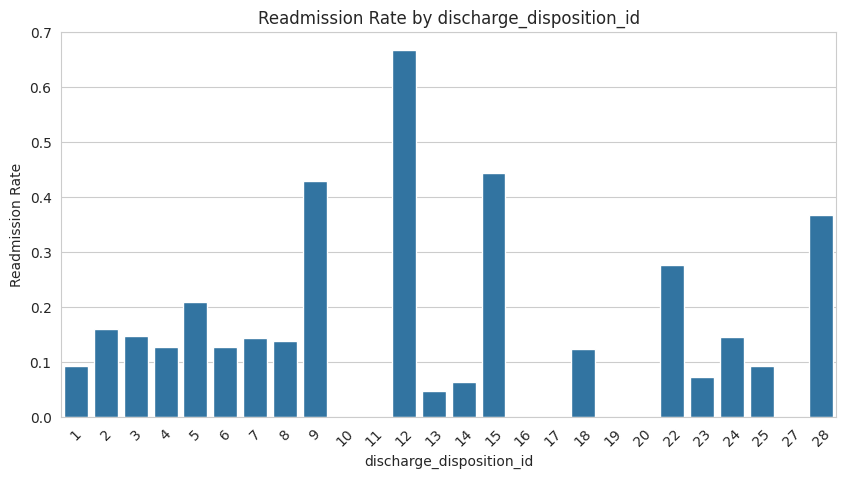

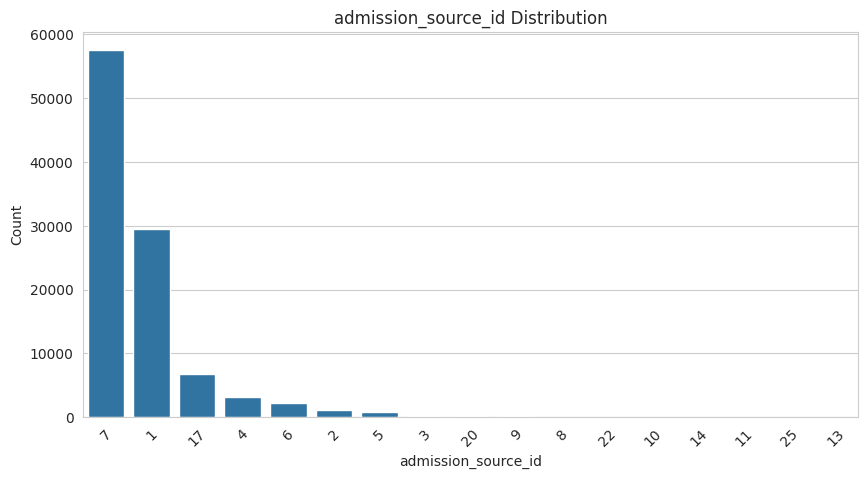

,admission_source_id,target
15,22,0.166667
2,3,0.155080
14,20,0.136646
7,8,0.125000
4,5,0.118129
6,7,0.116886
0,1,0.105872
13,17,0.104114
8,9,0.104000
1,2,0.100543


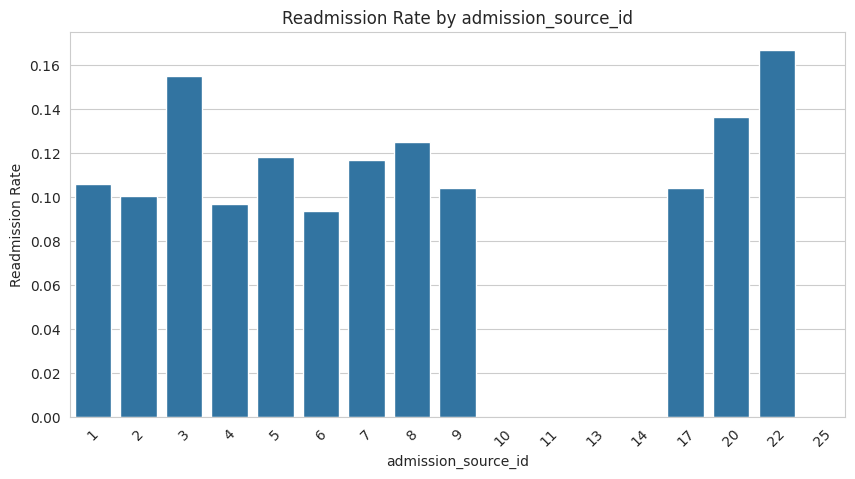

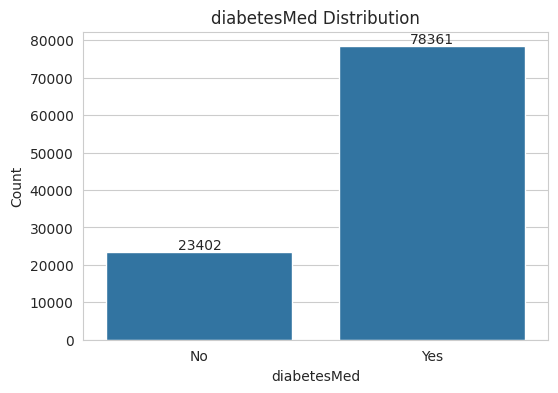

,diabetesMed,target
1,Yes,0.116270
0,No,0.095975


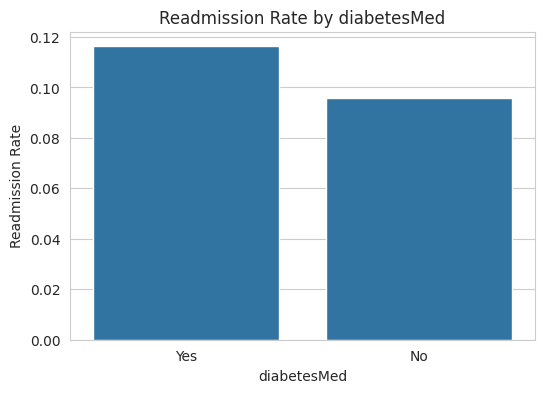

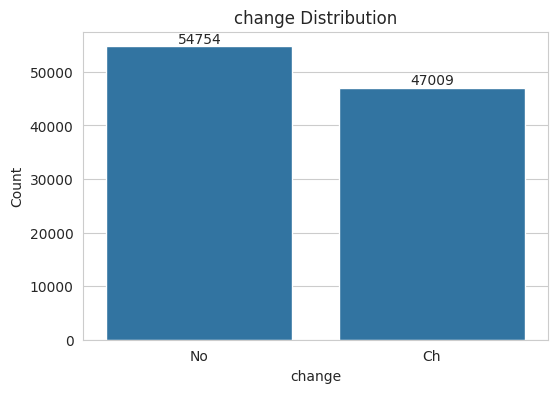

,change,target
0,Ch,0.118233
1,No,0.105910


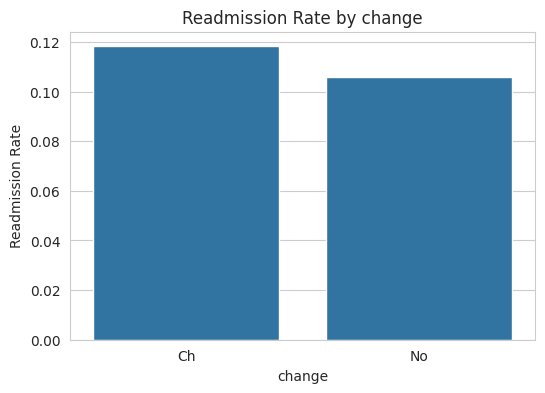

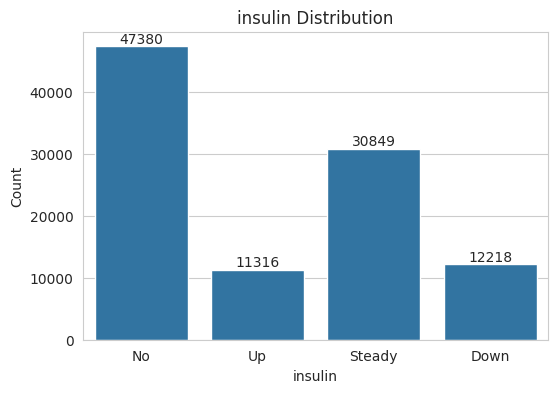

,insulin,target
0,Down,0.138975
3,Up,0.129905
2,Steady,0.111284
1,No,0.100380


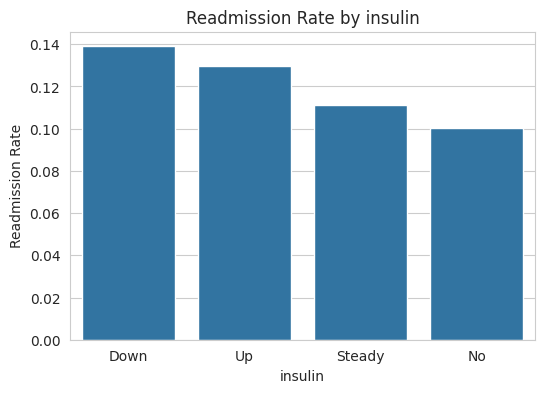

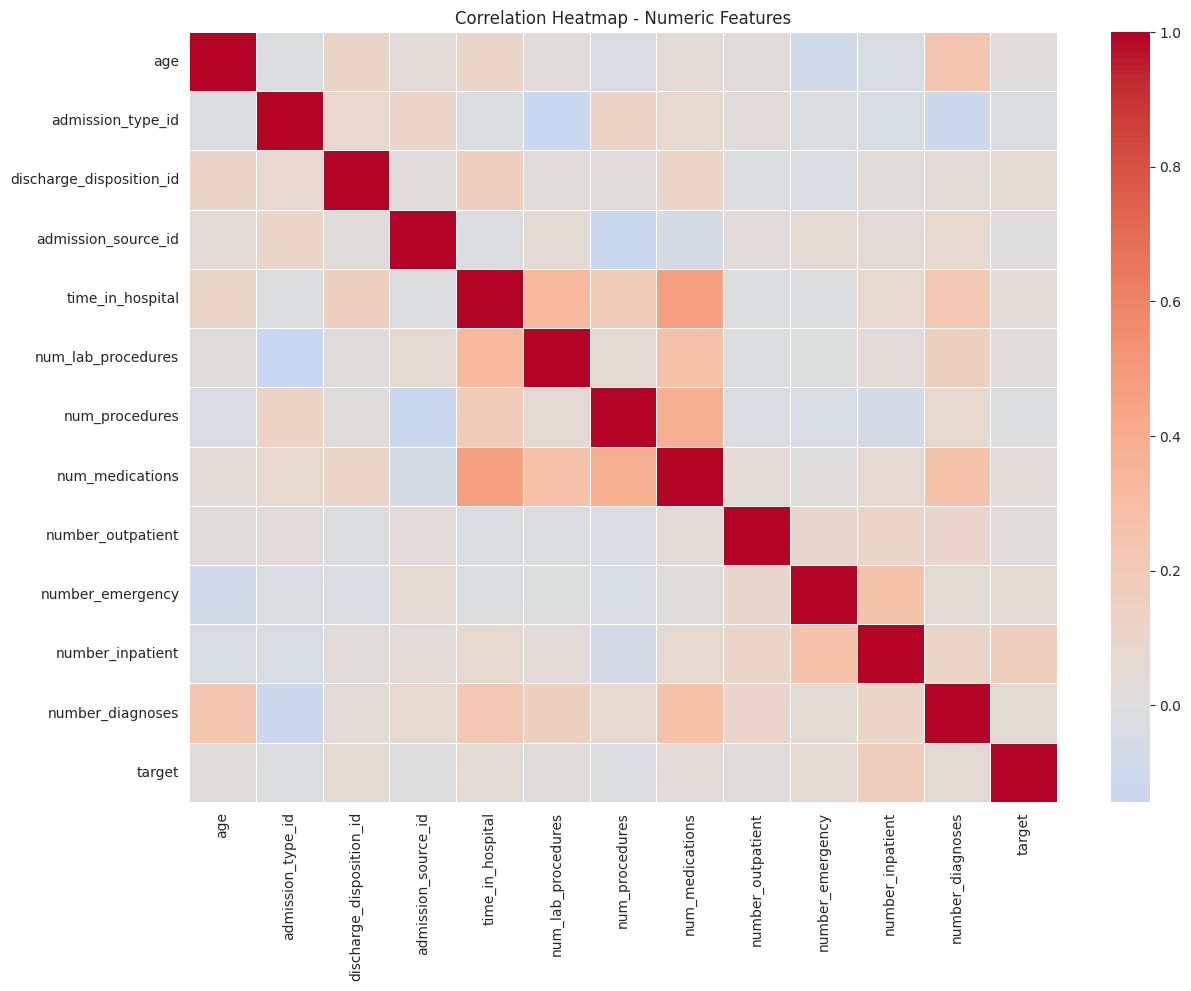

/tmp/ipykernel_11667/186939857.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df.groupby(f"{col}_bin")["target"].mean().reset_index()


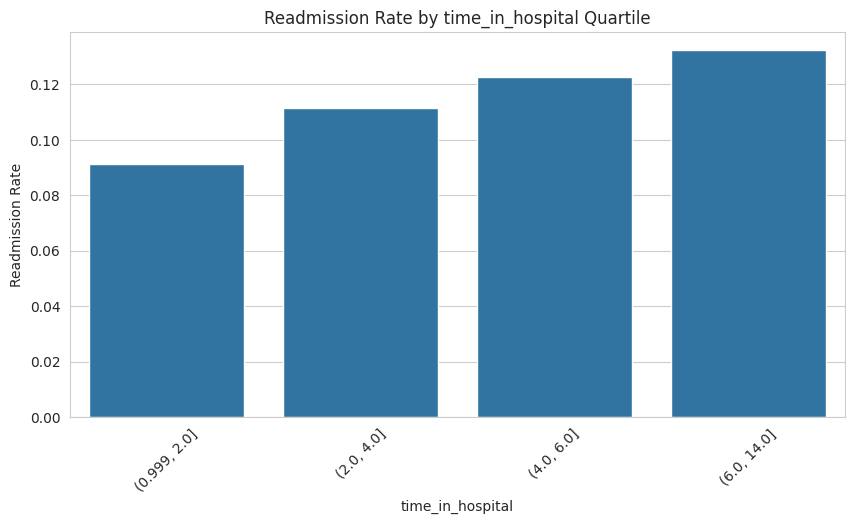

/tmp/ipykernel_11667/186939857.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df.groupby(f"{col}_bin")["target"].mean().reset_index()


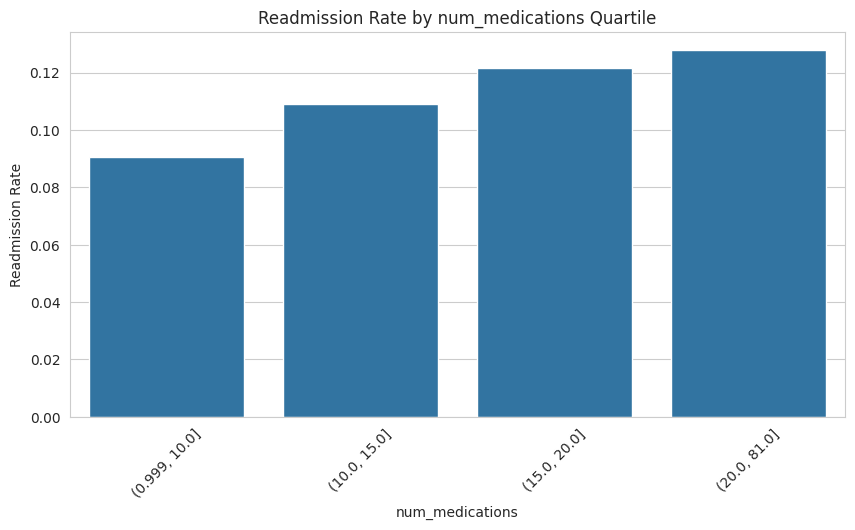

/tmp/ipykernel_11667/186939857.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df.groupby(f"{col}_bin")["target"].mean().reset_index()


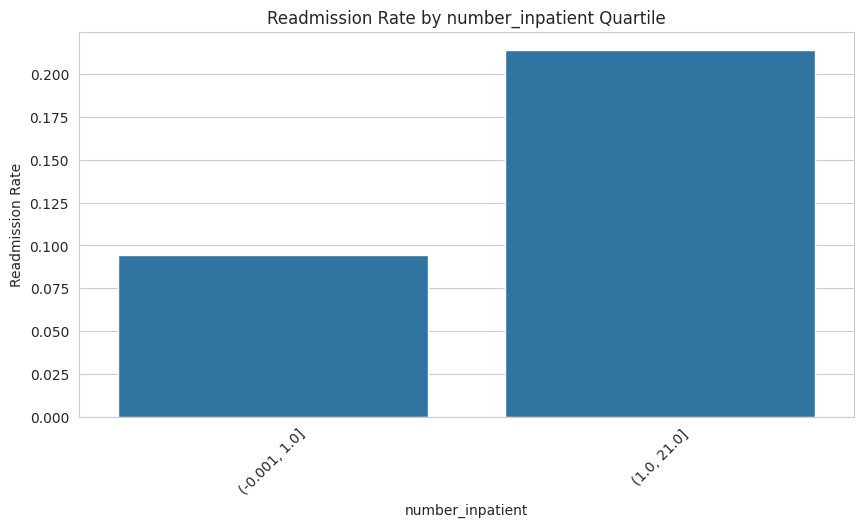

/tmp/ipykernel_11667/186939857.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df.groupby(f"{col}_bin")["target"].mean().reset_index()


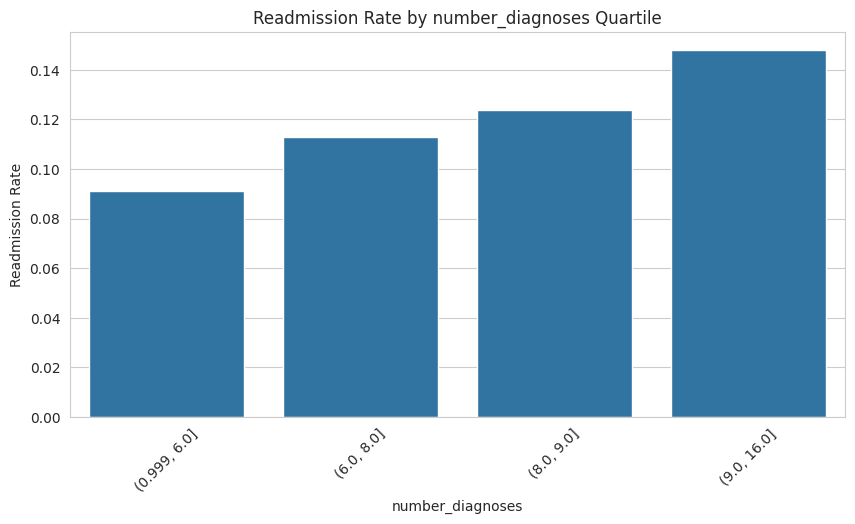

Mean values by target:


,time_in_hospital,num_medications,number_inpatient,number_diagnoses
target,,,,
0,4.35,15.91,0.56,7.39
1,4.77,16.90,1.22,7.69


Categorical readmission summaries:

gender:


,gender,target
0,Female,0.112452
1,Male,0.110615



race:


...


diabetesMed:


,diabetesMed,target
0,Yes,0.116270
1,No,0.095975



change:


,change,target
0,Ch,0.118233
1,No,0.105910



EDA complete. Summary files saved.


In [4]:
# =========================================
# 02_EDA.ipynb
# Predicting 30-Day Hospital Readmission Risk
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# -----------------------------------------
# 1. Load cleaned data
# -----------------------------------------
df = pd.read_csv("diabetic_data_cleaned.csv")

print("Shape:", df.shape)
display(df.head())

# -----------------------------------------
# 2. Basic overview
# -----------------------------------------
print("\nInfo:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)

print("\nTarget distribution (%):")
display((df["target"].value_counts(normalize=True) * 100).round(2))

# -----------------------------------------
# 3. Missing values check
# -----------------------------------------
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": (df.isnull().mean() * 100).round(2)
})
missing = missing[missing["Missing_Count"] > 0].sort_values("Missing_%", ascending=False)

print("\nMissing values:")
display(missing)

# -----------------------------------------
# 4. Helper function for plotting
# -----------------------------------------
def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container)

# -----------------------------------------
# 5. Target distribution
# -----------------------------------------
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="target")
plt.title("30-Day Readmission Distribution")
plt.xlabel("Target (1 = Readmitted within 30 days)")
plt.ylabel("Count")
add_labels(ax)
plt.show()

# -----------------------------------------
# 6. Age distribution and readmission risk by age
# -----------------------------------------
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x="age", order=sorted(df["age"].unique()))
plt.title("Age Distribution")
plt.xlabel("Age (midpoint)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

age_risk = df.groupby("age")["target"].mean().reset_index()
age_risk = age_risk.sort_values("age")

plt.figure(figsize=(10,5))
sns.lineplot(data=age_risk, x="age", y="target", marker="o")
plt.title("Readmission Risk by Age")
plt.xlabel("Age (midpoint)")
plt.ylabel("Readmission Rate")
plt.xticks(rotation=45)
plt.show()

display(age_risk)

# -----------------------------------------
# 7. Gender distribution
# -----------------------------------------
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
add_labels(ax)
plt.show()

gender_risk = df.groupby("gender")["target"].mean().reset_index()
display(gender_risk)

plt.figure(figsize=(6,4))
sns.barplot(data=gender_risk, x="gender", y="target")
plt.title("Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Readmission Rate")
plt.show()

# -----------------------------------------
# 8. Race distribution
# -----------------------------------------
plt.figure(figsize=(12,5))
ax = sns.countplot(data=df, x="race", order=df["race"].value_counts().index)
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
add_labels(ax)
plt.show()

race_risk = df.groupby("race")["target"].mean().reset_index().sort_values("target", ascending=False)
display(race_risk)

plt.figure(figsize=(12,5))
sns.barplot(data=race_risk, x="race", y="target")
plt.title("Readmission Rate by Race")
plt.xlabel("Race")
plt.ylabel("Readmission Rate")
plt.xticks(rotation=45)
plt.show()

# -----------------------------------------
# 9. Hospital utilization analysis
# -----------------------------------------
util_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

for col in util_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="target", y=col)
    plt.title(f"{col} vs Readmission")
    plt.xlabel("Target (1 = Readmitted within 30 days)")
    plt.ylabel(col)
    plt.show()

# Mean comparison table
util_summary = df.groupby("target")[util_cols].mean().round(2)
display(util_summary)

# -----------------------------------------
# 10. Statistical tests (Mann-Whitney U)
# -----------------------------------------
print("Mann-Whitney U test results:")
for col in ["time_in_hospital", "num_medications", "number_inpatient", "number_diagnoses"]:
    group0 = df[df["target"] == 0][col]
    group1 = df[df["target"] == 1][col]
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    print(f"{col}: p-value = {p:.10f}")

# -----------------------------------------
# 11. Admission-related variables
# -----------------------------------------
admission_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

for col in admission_cols:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

    risk = df.groupby(col)["target"].mean().reset_index().sort_values("target", ascending=False)
    display(risk)

    plt.figure(figsize=(10,5))
    sns.barplot(data=risk, x=col, y="target")
    plt.title(f"Readmission Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Readmission Rate")
    plt.xticks(rotation=45)
    plt.show()

# -----------------------------------------
# 12. Diabetes medication-related variables
# -----------------------------------------
med_cols = [
    "diabetesMed",
    "change",
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin"
]

for col in ["diabetesMed", "change", "insulin"]:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    add_labels(ax)
    plt.show()

    risk = df.groupby(col)["target"].mean().reset_index().sort_values("target", ascending=False)
    display(risk)

    plt.figure(figsize=(6,4))
    sns.barplot(data=risk, x=col, y="target")
    plt.title(f"Readmission Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Readmission Rate")
    plt.show()

# Optional: list of medication columns to inspect prevalence
med_summary = {}
for col in med_cols:
    if col in df.columns:
        med_summary[col] = df[col].value_counts(dropna=False).to_dict()

# -----------------------------------------
# 13. Correlation heatmap for numeric columns
# -----------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

# -----------------------------------------
# 14. Readmission rate by bins
# -----------------------------------------
bin_cols = ["time_in_hospital", "num_medications", "number_inpatient", "number_diagnoses"]

for col in bin_cols:
    try:
        df[f"{col}_bin"] = pd.qcut(df[col], q=4, duplicates="drop")
        risk = df.groupby(f"{col}_bin")["target"].mean().reset_index()

        plt.figure(figsize=(10,5))
        sns.barplot(data=risk, x=f"{col}_bin", y="target")
        plt.title(f"Readmission Rate by {col} Quartile")
        plt.xlabel(col)
        plt.ylabel("Readmission Rate")
        plt.xticks(rotation=45)
        plt.show()
    except Exception as e:
        print(f"Could not bin {col}: {e}")

# -----------------------------------------
# 15. Top drivers summary tables
# -----------------------------------------
top_numeric = df.groupby("target")[["time_in_hospital", "num_medications", "number_inpatient", "number_diagnoses"]].mean().round(2)
print("Mean values by target:")
display(top_numeric)

top_categorical = {}
for col in ["gender", "race", "diabetesMed", "change"]:
    top_categorical[col] = df.groupby(col)["target"].mean().sort_values(ascending=False)

print("Categorical readmission summaries:")
for col, summary in top_categorical.items():
    print(f"\n{col}:")
    display(summary.reset_index())

# -----------------------------------------
# 16. Save EDA outputs
# -----------------------------------------
age_risk.to_csv("age_risk_summary.csv", index=False)
util_summary.to_csv("utilization_summary_by_target.csv")
missing.to_csv("missing_values_summary.csv")

print("\nEDA complete. Summary files saved.")

In [15]:
# =========================================
# 03_feature_engineering_and_model_prep.ipynb
# Corrected Complete Version
# =========================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from scipy import sparse

from IPython.display import display

# =========================================
# 1. Load cleaned data
# =========================================
df = pd.read_csv("diabetic_data_cleaned.csv")

print("Initial shape:", df.shape)
display(df.head())

df["target"] = df["target"].astype(int)

# =========================================
# 2. Feature Engineering
# =========================================

# -----------------------------------------
# 2.1 Utilization-based features
# -----------------------------------------
df["utilization_score"] = (
    df["number_outpatient"] +
    df["number_emergency"] +
    df["number_inpatient"]
)

df["prior_utilizer"] = (df["utilization_score"] > 0).astype(int)
df["frequent_admitter"] = (df["number_inpatient"] >= 2).astype(int)
df["long_stay_flag"] = (df["time_in_hospital"] >= 7).astype(int)
df["high_medication_burden"] = (df["num_medications"] >= 20).astype(int)
df["high_lab_burden"] = (df["num_lab_procedures"] >= 60).astype(int)
df["elderly_flag"] = (df["age"] >= 75).astype(int)

# Added useful complexity flag
df["complex_patient"] = (
    (df["number_diagnoses"] >= 8) &
    (df["num_medications"] >= 20)
).astype(int)

# -----------------------------------------
# 2.2 Risk bands
# -----------------------------------------
df["diagnosis_burden_level"] = pd.cut(
    df["number_diagnoses"],
    bins=[0, 5, 8, 16],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

df["utilization_level"] = pd.cut(
    df["utilization_score"],
    bins=[-1, 0, 2, 1000],
    labels=["None", "Low", "High"],
    include_lowest=True
)

df["medication_burden_level"] = pd.cut(
    df["num_medications"],
    bins=[0, 10, 20, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# -----------------------------------------
# 2.3 Medication-related flags
# -----------------------------------------
df["medication_changed_flag"] = (df["change"] == "Ch").astype(int)
df["on_diabetes_med_flag"] = (df["diabetesMed"] == "Yes").astype(int)

# Count how many drug classes are active
medication_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]
medication_cols = [col for col in medication_cols if col in df.columns]

df["active_medication_classes"] = (df[medication_cols] != "No").sum(axis=1)
df["up_medications"] = (df[medication_cols] == "Up").sum(axis=1)
df["down_medications"] = (df[medication_cols] == "Down").sum(axis=1)
df["steady_medications"] = (df[medication_cols] == "Steady").sum(axis=1)

# -----------------------------------------
# 2.4 ICD diagnosis grouping
# -----------------------------------------
def map_icd_group(code):
    """
    Map ICD-9 diagnosis codes to broad clinical groups.
    """
    if pd.isna(code):
        return "Unknown"

    code = str(code).strip()

    if code == "" or code == "Unknown":
        return "Unknown"

    # V-codes
    if code.startswith("V"):
        return "Supplementary"

    # E-codes
    if code.startswith("E"):
        return "External"

    try:
        num = float(code)
    except:
        return "Other"

    if 390 <= num <= 459 or num == 785:
        return "Circulatory"
    elif 460 <= num <= 519 or num == 786:
        return "Respiratory"
    elif 520 <= num <= 579 or num == 787:
        return "Digestive"
    elif 250 <= num < 251:
        return "Diabetes"
    elif 800 <= num <= 999:
        return "Injury"
    elif 710 <= num <= 739:
        return "Musculoskeletal"
    elif 580 <= num <= 629 or num == 788:
        return "Genitourinary"
    elif 140 <= num <= 239:
        return "Neoplasms"
    elif 240 <= num <= 279:
        return "Endocrine_Metabolic"
    else:
        return "Other"

for col in ["diag_1", "diag_2", "diag_3"]:
    if col in df.columns:
        df[col + "_group"] = df[col].apply(map_icd_group)

df["num_unique_dx_groups"] = df[
    ["diag_1_group", "diag_2_group", "diag_3_group"]
].nunique(axis=1)

df["has_diabetes_dx"] = df[
    ["diag_1_group", "diag_2_group", "diag_3_group"]
].eq("Diabetes").any(axis=1).astype(int)

df["multi_system_dx"] = (df["num_unique_dx_groups"] >= 2).astype(int)

# -----------------------------------------
# 2.5 Treat admission IDs as categorical
# -----------------------------------------
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    if col in df.columns:
        df[col] = df[col].astype(str)

# -----------------------------------------
# 2.6 Drop raw diagnosis columns after grouping
# -----------------------------------------
df.drop(
    columns=[col for col in ["diag_1", "diag_2", "diag_3"] if col in df.columns],
    inplace=True
)

# -----------------------------------------
# 2.7 Drop constant columns
# -----------------------------------------
constant_cols = [
    col for col in df.columns
    if col != "target" and df[col].nunique(dropna=False) <= 1
]

print("Constant columns dropped:", constant_cols)
df.drop(columns=constant_cols, inplace=True)

# -----------------------------------------
# 2.8 Save engineered dataset
# -----------------------------------------
df.to_csv("diabetic_data_feature_engineered.csv", index=False)

print("\nSaved engineered dataset as diabetic_data_feature_engineered.csv")
print("\nEngineered shape:", df.shape)
display(df.head())

# =========================================
# 3. Data Preparation for Modeling
# =========================================

X = df.drop(columns=["target"])
y = df["target"].astype(int)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

# Column types
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# Fit and transform
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("\nPrepared train shape:", X_train_prepared.shape)
print("Prepared test shape:", X_test_prepared.shape)

# Feature names
feature_names = preprocessor.get_feature_names_out()
print("\nTotal encoded features:", len(feature_names))

# =========================================
# 4. Save artifacts
# =========================================
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(feature_names, "feature_names.pkl")
joblib.dump(X_train.columns.tolist(), "original_feature_columns.pkl")

np.save("y_train.npy", y_train.to_numpy())
np.save("y_test.npy", y_test.to_numpy())

if sparse.issparse(X_train_prepared):
    sparse.save_npz("X_train_prepared.npz", X_train_prepared)
    sparse.save_npz("X_test_prepared.npz", X_test_prepared)
else:
    np.save("X_train_prepared.npy", X_train_prepared)
    np.save("X_test_prepared.npy", X_test_prepared)

print("\nSaved preprocessing artifacts successfully.")

Initial shape: (101763, 43)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,Caucasian,Female,5,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,15,1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,35,1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,45,1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0


Constant columns dropped: ['examide', 'citoglipton']

Saved engineered dataset as diabetic_data_feature_engineered.csv

Engineered shape: (101763, 61)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,active_medication_classes,up_medications,down_medications,steady_medications,diag_1_group,diag_2_group,diag_3_group,num_unique_dx_groups,has_diabetes_dx,multi_system_dx
0,Caucasian,Female,5,6,25,1,1,41,0,1,...,0,0,0,0,Diabetes,Unknown,Unknown,2,1,1
1,Caucasian,Female,15,1,1,7,3,59,0,18,...,1,1,0,0,Endocrine_Metabolic,Diabetes,Endocrine_Metabolic,2,1,1
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,...,1,0,0,1,Other,Diabetes,Supplementary,3,1,1
3,Caucasian,Male,35,1,1,7,2,44,1,16,...,1,1,0,0,Other,Diabetes,Circulatory,3,1,1
4,Caucasian,Male,45,1,1,7,1,51,0,8,...,2,0,0,2,Neoplasms,Neoplasms,Diabetes,2,1,1



Feature matrix shape: (101763, 60)
Target shape: (101763,)

Train shape: (81410, 60)
Test shape: (20353, 60)

Train target distribution (%):
target
0    88.84
1    11.16
Name: proportion, dtype: float64

Test target distribution (%):
target
0    88.84
1    11.16
Name: proportion, dtype: float64

Numeric columns: 26
Categorical columns: 34

Prepared train shape: (81410, 203)
Prepared test shape: (20353, 203)

Total encoded features: 203

Saved preprocessing artifacts successfully.


X_train_prepared: <class 'scipy.sparse._csr.csr_matrix'> (81410, 203)
X_test_prepared: <class 'scipy.sparse._csr.csr_matrix'> (20353, 203)
y_train: <class 'pandas.core.series.Series'> (81410,)
y_test: <class 'pandas.core.series.Series'> (20353,)
feature_names: 203

Logistic Regression Results
----------------------------------------
Accuracy: 0.6651
Precision: 0.1829
Recall: 0.5773
F1 Score: 0.2778
ROC-AUC: 0.6778
PR-AUC: 0.2181

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.68      0.78     18082
           1       0.18      0.58      0.28      2271

    accuracy                           0.67     20353
   macro avg       0.56      0.63      0.53     20353
weighted avg       0.84      0.67      0.73     20353


Random Forest Results
----------------------------------------
Accuracy: 0.7275
Precision: 0.2017
Recall: 0.4879
F1 Score: 0.2855
ROC-AUC: 0.6804
PR-AUC: 0.2242

Classification Report:

              precision    r

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
1,Random Forest,0.727460,0.201748,0.487891,0.285457,0.680362,0.224174
2,XGBoost,0.670958,0.186899,0.581682,0.282900,0.686968,0.236653
0,Logistic Regression,0.665062,0.182896,0.577279,0.277784,0.677832,0.218059


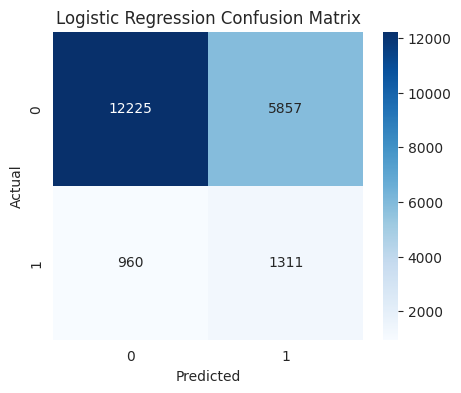

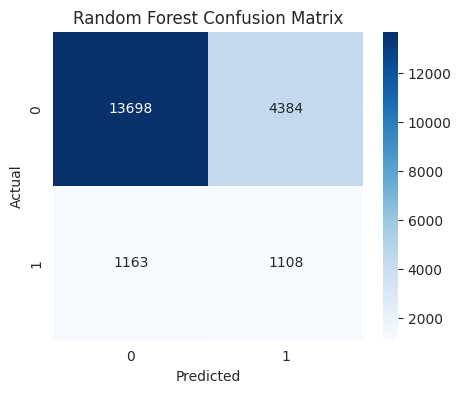

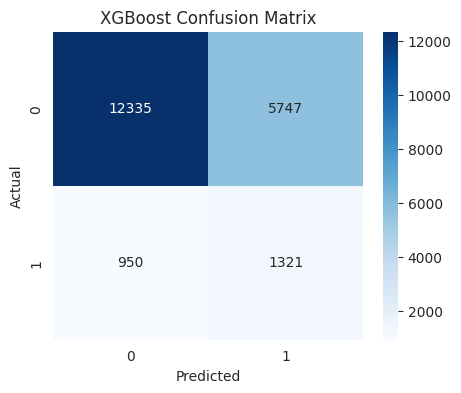

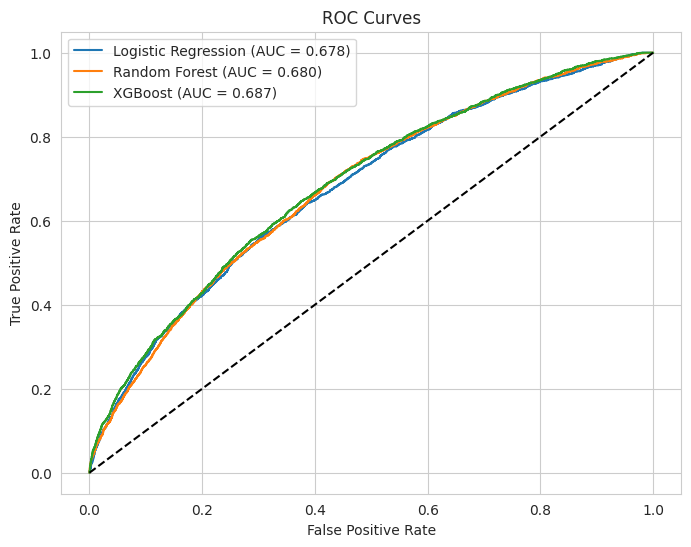

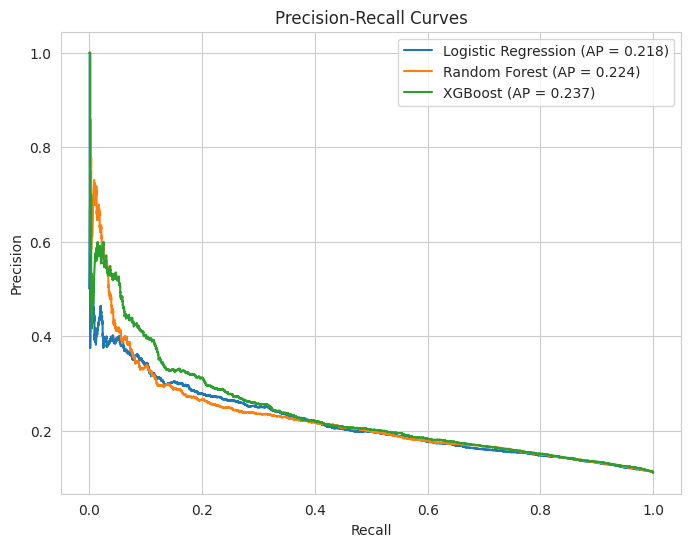

,feature,importance
11,num__frequent_admitter,0.119641
10,num__prior_utilizer,0.040871
42,cat__discharge_disposition_id_1,0.032733
7,num__number_inpatient,0.028095
44,cat__discharge_disposition_id_11,0.025799
55,cat__discharge_disposition_id_22,0.018618
158,cat__utilization_level_High,0.014990
153,cat__diabetesMed_No,0.010412
63,cat__discharge_disposition_id_5,0.010076
9,num__utilization_score,0.008864


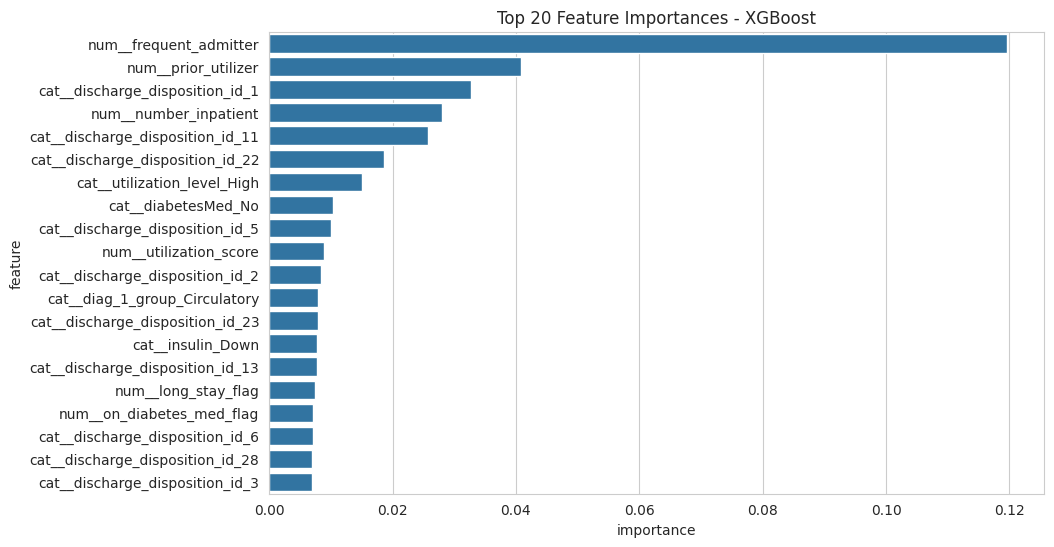

Saved xgb_model.pkl


In [16]:
# =========================================
# 04_model_building.ipynb
# Corrected Complete Version
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

# -----------------------------------------
# 1. Check that Step 3 variables exist
# -----------------------------------------
print("X_train_prepared:", type(X_train_prepared), getattr(X_train_prepared, "shape", None))
print("X_test_prepared:", type(X_test_prepared), getattr(X_test_prepared, "shape", None))
print("y_train:", type(y_train), getattr(y_train, "shape", None))
print("y_test:", type(y_test), getattr(y_test, "shape", None))
print("feature_names:", len(feature_names))

# If y_train/y_test are pandas Series, convert to numpy arrays for consistency
y_train = np.array(y_train)
y_test = np.array(y_test)

# -----------------------------------------
# 2. Logistic Regression
# -----------------------------------------
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
    solver="liblinear"
)

log_reg.fit(X_train_prepared, y_train)

y_pred_lr = log_reg.predict(X_test_prepared)
y_prob_lr = log_reg.predict_proba(X_test_prepared)[:, 1]

print("\nLogistic Regression Results")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_lr), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# -----------------------------------------
# 3. Random Forest
# -----------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_prepared, y_train)

y_pred_rf = rf.predict(X_test_prepared)
y_prob_rf = rf.predict_proba(X_test_prepared)[:, 1]

print("\nRandom Forest Results")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_rf), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# -----------------------------------------
# 4. XGBoost
# -----------------------------------------
pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_ratio,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_prepared, y_train)

y_pred_xgb = xgb.predict(X_test_prepared)
y_prob_xgb = xgb.predict_proba(X_test_prepared)[:, 1]

print("\nXGBoost Results")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_xgb), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# -----------------------------------------
# 5. Compare models
# -----------------------------------------
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
})

display(results.sort_values("F1 Score", ascending=False))

# -----------------------------------------
# 6. Confusion matrix plot
# -----------------------------------------
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")

# -----------------------------------------
# 7. ROC curves
# -----------------------------------------
plt.figure(figsize=(8,6))

for name, y_prob in [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest", y_prob_rf),
    ("XGBoost", y_prob_xgb)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# -----------------------------------------
# 8. Precision-Recall curves
# -----------------------------------------
plt.figure(figsize=(8,6))

for name, y_prob in [
    ("Logistic Regression", y_prob_lr),
    ("Random Forest", y_prob_rf),
    ("XGBoost", y_prob_xgb)
]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

# -----------------------------------------
# 9. Feature importance for XGBoost
# -----------------------------------------
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(20))

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances - XGBoost")
plt.show()

# -----------------------------------------
# 10. Save best model
# -----------------------------------------
joblib.dump(xgb, "xgb_model.pkl")
print("Saved xgb_model.pkl")

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# use XGBoost probabilities
y_prob = y_prob_xgb

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

results = []
for t in np.arange(0.05, 0.95, 0.01):
    y_pred_thr = (y_prob >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1": f1_score(y_test, y_pred_thr, zero_division=0)
    })

threshold_df = pd.DataFrame(results)

display(threshold_df.sort_values("f1", ascending=False).head(10))
display(threshold_df.sort_values("recall", ascending=False).head(10))

,threshold,precision,recall,f1
48,0.53,0.201995,0.508146,0.289078
47,0.52,0.197531,0.535447,0.288596
49,0.54,0.204958,0.476882,0.286698
50,0.55,0.209854,0.448261,0.285875
46,0.51,0.191808,0.558785,0.285586
52,0.57,0.220896,0.399384,0.284460
51,0.56,0.213556,0.423162,0.283858
45,0.50,0.186899,0.581682,0.282900
54,0.59,0.233796,0.355790,0.282172
55,0.60,0.242540,0.336416,0.281867


,threshold,precision,recall,f1
0,0.05,0.113471,1.000000,0.203814
1,0.06,0.113471,1.000000,0.203814
2,0.07,0.113476,1.000000,0.203823
3,0.08,0.113449,0.999560,0.203770
4,0.09,0.113500,0.999560,0.203853
5,0.10,0.113551,0.999560,0.203935
6,0.11,0.113608,0.999560,0.204027
7,0.12,0.113632,0.999119,0.204056
8,0.13,0.113786,0.999119,0.204304
9,0.14,0.113924,0.998679,0.204518


In [18]:
best_threshold = 0.53

In [19]:
y_pred_final = (y_prob_xgb >= 0.53).astype(int)

In [20]:
!pip install shap -q

SHAP

In [21]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test_prepared)

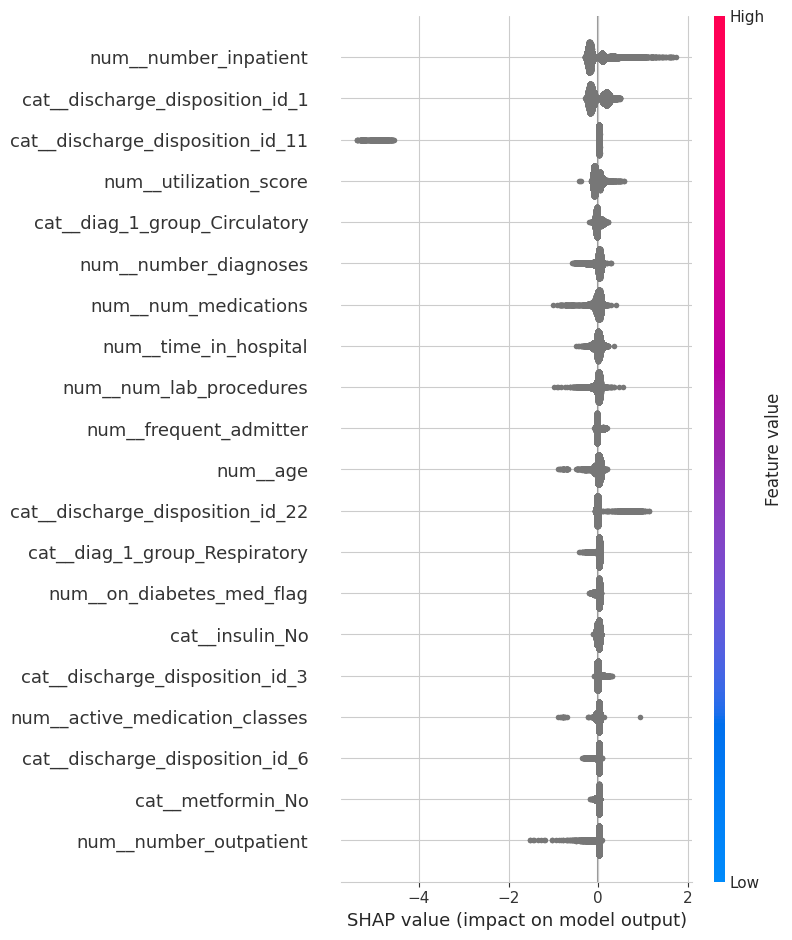

In [23]:
shap.summary_plot(
    shap_values,
    X_test_prepared,
    feature_names=feature_names
)

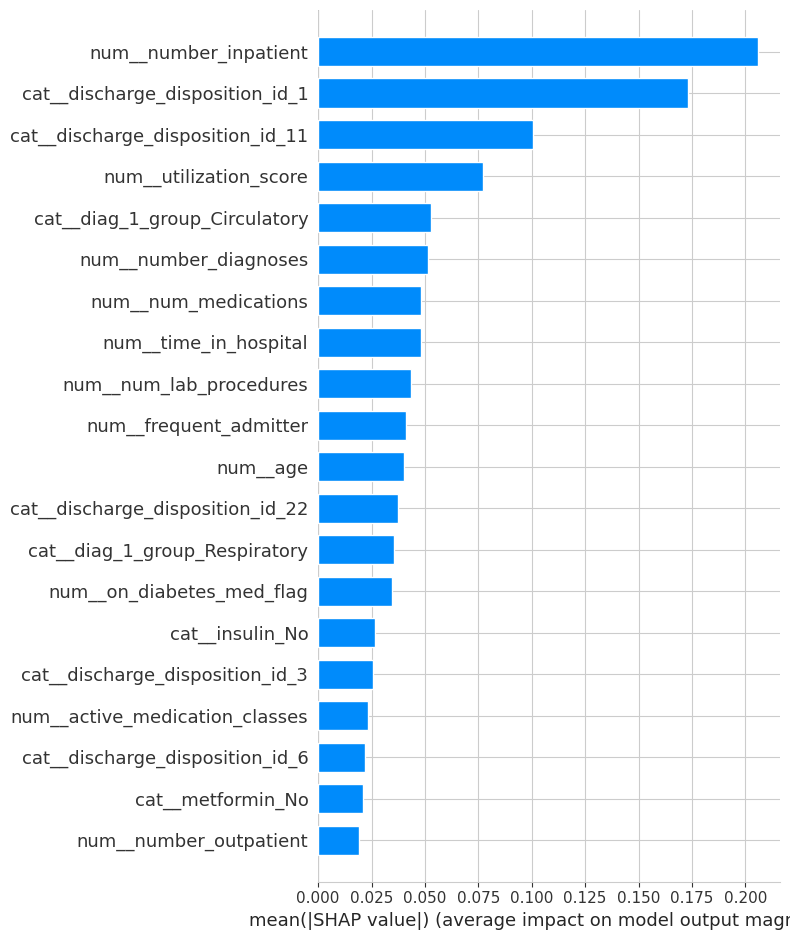

In [24]:
shap.summary_plot(
    shap_values,
    X_test_prepared,
    feature_names=feature_names,
    plot_type="bar"
)

In [25]:
high_risk_idx = np.argmax(y_prob_xgb)

print(
    "Predicted Probability:",
    y_prob_xgb[high_risk_idx]
)

Predicted Probability: 0.94702756


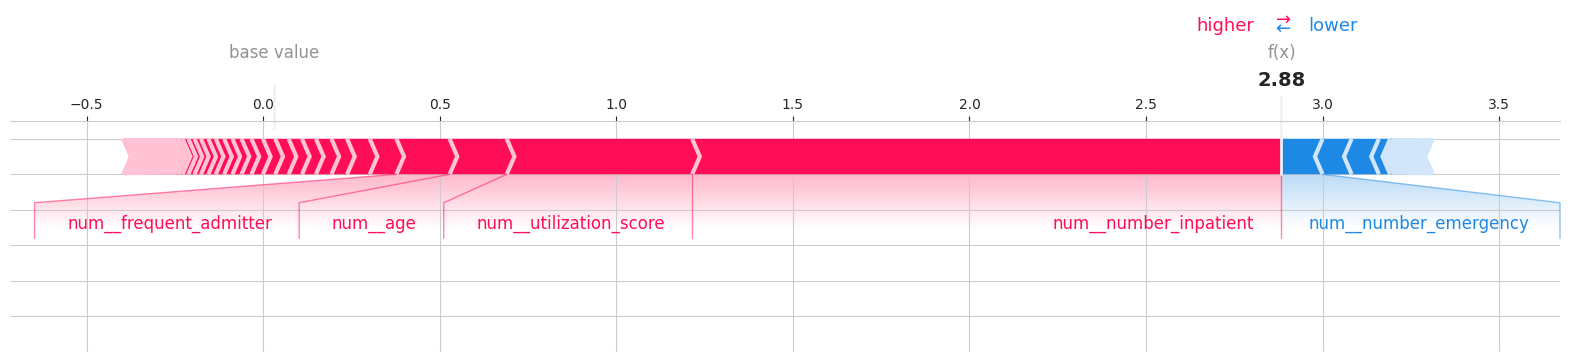

In [26]:
shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    feature_names=feature_names,
    matplotlib=True
)

In [27]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values).mean(axis=0)
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

importance_df.head(20)

,feature,importance
7,num__number_inpatient,0.205928
42,cat__discharge_disposition_id_1,0.173128
44,cat__discharge_disposition_id_11,0.100536
9,num__utilization_score,0.077202
164,cat__diag_1_group_Circulatory,0.052715
8,num__number_diagnoses,0.051416
4,num__num_medications,0.048323
1,num__time_in_hospital,0.048273
2,num__num_lab_procedures,0.043519
11,num__frequent_admitter,0.040920


In [28]:
importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)